<a href="https://colab.research.google.com/github/Wdwood12/1-Data620_26_Centrality_Proposal/blob/main/DATA_620_%E2%80%93_Network_Analysis_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Southern Women Bipartite Network Analysis

Woodelyne Durosier
DATA 620 – Network Analysis and Visualization
March 2026

 **Introduction**

The 1941 sociological study that looked at women's social involvement patterns in a Southern community is the source of the Davis Southern Women dataset. The dataset creates a bipartite network structure by tracking the attendance of eighteen women at fourteen social gatherings. Two distinct kinds of nodes make up bipartite networks, where connections only take place between the two groups.

In this instance, ladies and social events are represented by the two node sets. A woman's presence at an event is indicated by an edge between her and the event. Researchers can examine participation trends as well as the indirect connections made through common social activities thanks to this framework.

This research uses NetworkX in Python to investigate the connections between the ladies and the events they attended. Through the projection of the bipartite network into one-mode networks, we may investigate the social connections between individuals and the shared participation in events.



In [ ]:

# Import Libraries

import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

# With the help of these libraries, we can create and examine the network structure and see how nodes relate to one another.
# Load the Dataset

G = nx.davis_southern_women_graph()

women = G.graph["top"]
clubs = G.graph["bottom"]

# The Davis Southern Women dataset is a built-in example provided by NetworkX. There are two partitions in the graph:

# Women (top nodes)

# Social gatherings (bottom nodes)
# A woman's involvement in a certain event is represented by each edge.
# Biadjacency Matrix

print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

# The network's bipartite structure is represented by the biadjacency matrix.

# # Women are represented by rows.
# Events are represented by columns.
# Attendance is indicated by a number of one.
# No participation is indicated by a value of 0.
# Because it formally captures all attendance relationships between the two node sets, the matrix representation is helpful for computational analysis. Each person only attends a portion of the total events, which is reflected in the sparse structure of the matrix.
# Projection onto the Women Network

W = bipartite.projected_graph(G, women);

print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")

# If two women attend at least one event together, they are connected in a one-mode network created by projecting the bipartite network onto the female nodes.

# # The amount of other women that each person attends events with is represented by the degree value. Higher degree-valued women seem to be more socially connected and probably engaged in a wider variety of community activities.

# We are able to deduce social cohesiveness and individual interaction patterns inside the group thanks to this projection.




Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1
#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
17

In [7]:
# Weighted Projection

W = bipartite.weighted_projected_graph(G, women)

print("#Friend meetings, Member")
for w in women:
    print(f"{W.degree(w, weight='weight')} {w}")

# By gauging the quality of relationships between women, the weighted projection expands the analysis.

# The weighted network counts the number of events that two women attended together rather than just whether they attended the same event. Stronger or more frequent social interaction is indicated by higher weighted scores.

# This method offers more information on the strength of social connections inside the network.

#Friend meetings, Member
50 Evelyn Jefferson
45 Laura Mandeville
57 Theresa Anderson
46 Brenda Rogers
24 Charlotte McDowd
32 Frances Anderson
36 Eleanor Nye
31 Pearl Oglethorpe
40 Ruth DeSand
38 Verne Sanderson
33 Myra Liddel
37 Katherina Rogers
46 Sylvia Avondale
43 Nora Fayette
34 Helen Lloyd
24 Dorothy Murchison
14 Olivia Carleton
14 Flora Price


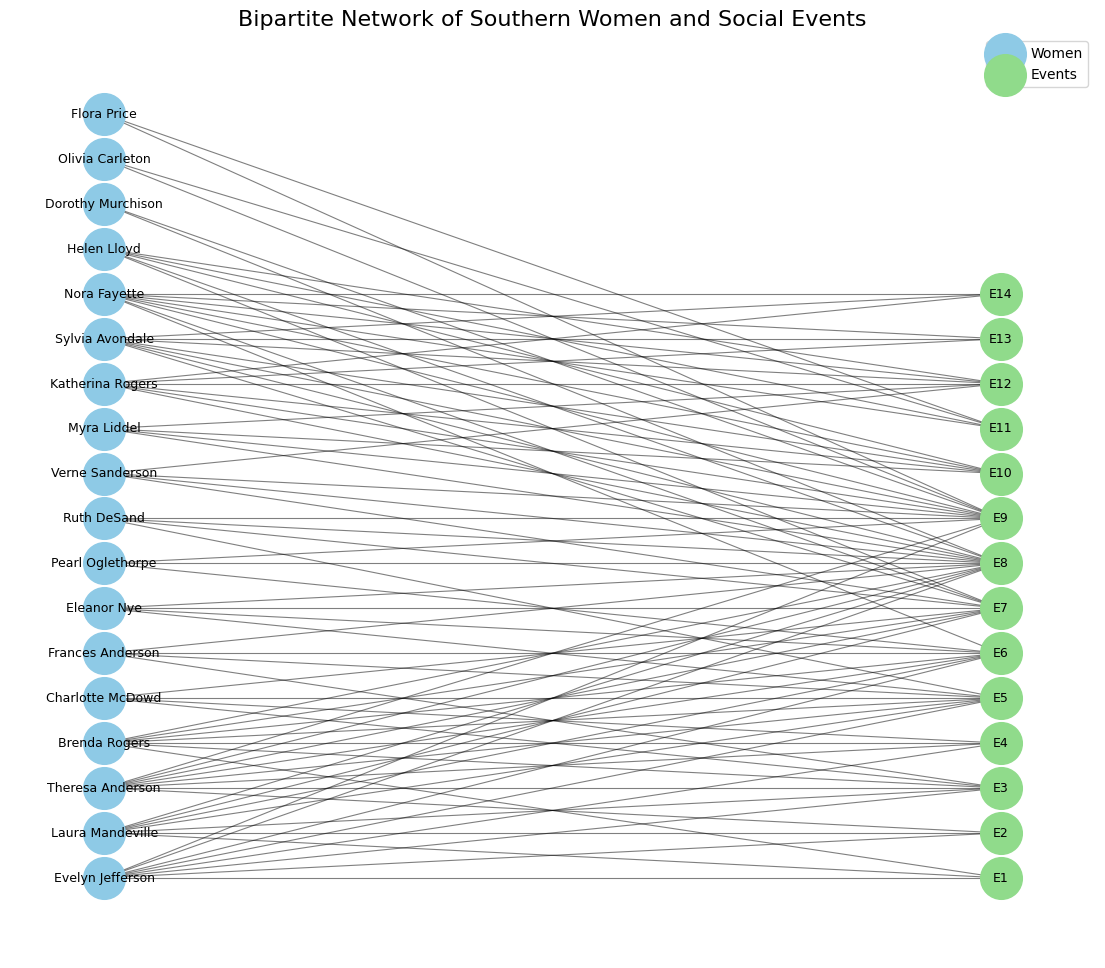

In [12]:
#  Network Visualization

pos = {}

pos.update((node, (0, i*2)) for i, node in enumerate(women))
pos.update((node, (4, i*2)) for i, node in enumerate(clubs))

plt.figure(figsize=(14,12))

# Draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=women,
                       node_color="#8ecae6",
                       node_size=900,
                       label="Women")

nx.draw_networkx_nodes(G, pos, nodelist=clubs,
                       node_color="#90db8b",
                       node_size=900,
                       label="Events")

# Draw edges
nx.draw_networkx_edges(G, pos,
                       width=0.8,
                       alpha=0.5)

# Labels
nx.draw_networkx_labels(G, pos,
                        font_size=9)

plt.title("Bipartite Network of Southern Women and Social Events", fontsize=16)

plt.legend(scatterpoints=1)
plt.axis("off")
plt.show()
# The bipartite network structure that links women to social events is seen in the visualization. Clusters and shared involvement patterns are made obvious by the layout algorithm, which places nodes according to their relationships.

# The dataset's general structure may be shown by visualizing the network, which also emphasizes how events act as hubs for participant interaction.

The bipartite network that links women to the social gatherings they attended is depicted in the visualization. To clearly show the involvement links between the two node sets, women and events are divided into two layers.

This arrangement draws attention to the bipartite structure and facilitates the observation of shared participation patterns across events.

**Understanding Relationships**

**Interactions Among the Women**

Many of the ladies are connected through shared event attendance, as seen by the predicted network. People who often show up at various events develop into key nodes in the social network. By bridging various social groups, these women might have been crucial in preserving social cohesiveness within the society.

Differences in connectivity imply that some women participated more actively in community events, while others attended less events and so had fewer social connections.

**Connections Among Social Events**

Indirect connections are made between events and the people who attended them. The network structure becomes tightly connected when a large number of women attend several events at once.

Events with a large number of attendance might be seen as social hubs, signifying get-togethers that drew a diverse group of people. These gatherings probably had a major impact on fostering communal interactions.



**Conclusion**

Participating in community events together helps foster social relationships, as seen by the Davis Southern Women dataset. We can gain a better understanding of social connectedness and participation patterns by projecting the dataset into one-mode networks after describing it as a bipartite network.

The analysis demonstrates that relationships between people are developed through co-participation in common activities as well as direct engagement. Similarly, overlapping participants connect the events themselves, exposing the community's social structure.

The Davis Southern Women dataset continues to be a crucial standard for assessing network analysis methods and algorithms due to its lucid depiction of social interaction patterns.



**References**

Davis, A., Gardner, B., & Gardner, M. (1941). Deep South: A Social Anthropological Study of Caste and Class. University of Chicago Press.

Hagberg, A., Schult, D., & Swart, P. (2008). Exploring network structure, dynamics, and function using NetworkX. Proceedings of the 7th Python in Science Conference, 11–15.

NetworkX Developers. (2024). Davis Southern Women Graph Example.

https://networkx.org/documentation/stable/auto_examples/algorithms/plot_davis_club.html